In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)


In [5]:
import os
print(os.listdir("."))

['.config', 'data', 'sample_data']


In [7]:
import os
print(os.listdir("."))

['.config', 'data', 'sample_data']


In [8]:
import os, shutil

os.makedirs("data", exist_ok=True)
shutil.move("sample_data/churn-bigml-80.csv", "data/churn-bigml-80.csv")
shutil.move("sample_data/churn-bigml-20.csv", "data/churn-bigml-20.csv")

print(os.listdir("data"))

['churn-bigml-80.csv', 'churn-bigml-20.csv']


In [10]:
def load_and_prep(path):
    df = pd.read_csv(path)
    df["International plan"] = df["International plan"].map({"Yes": 1, "No": 0})
    df["Voice mail plan"] = df["Voice mail plan"].map({"Yes": 1, "No": 0})
    df["Churn"] = df["Churn"].astype(int)
    # State/Area code dropped: too high-cardinality / low predictive value for a linear model
    df = df.drop(columns=["State", "Area code"])
    return df

train_df = load_and_prep("data/churn-bigml-80.csv")
test_df = load_and_prep("data/churn-bigml-20.csv")

X_train, y_train = train_df.drop(columns=["Churn"]), train_df["Churn"]
X_test, y_test = test_df.drop(columns=["Churn"]), test_df["Churn"]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("\nChurn rate (train):", y_train.mean().round(3))
train_df.head()


Train: (2666, 17) Test: (667, 17)

Churn rate (train): 0.146


,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [12]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]


Customer service calls    2.134286
International plan        2.060527
Number vmail messages     1.643077
Total day minutes         1.395929
Total day charge          1.395605
Total eve minutes         1.148306
Total eve charge          1.146836
Total intl charge         1.118841
Total intl minutes        1.111254
Total night minutes       1.075930
Total night charge        1.074696
Total day calls           1.050835
Account length            1.032956
Total night calls         1.012049
Total eve calls           1.005976
Total intl calls          0.812081
Voice mail plan           0.430902
dtype: float64


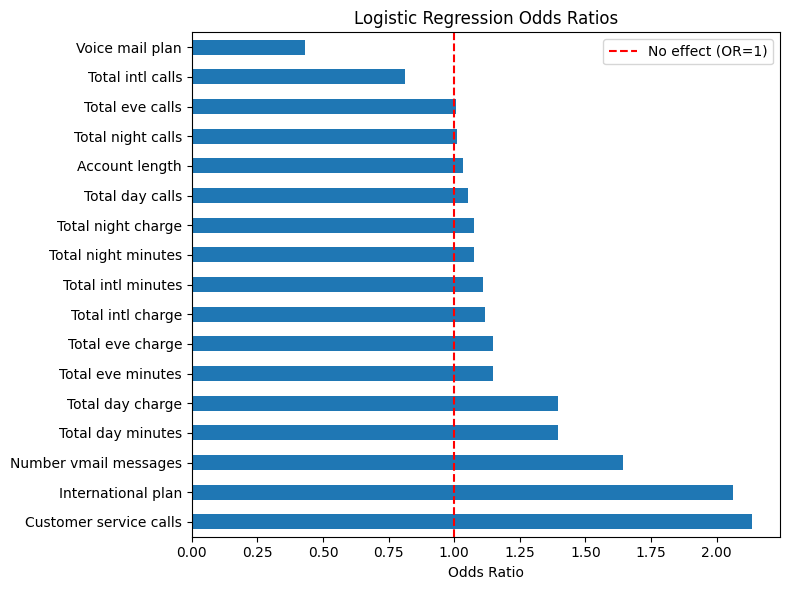

In [13]:
odds_ratios = pd.Series(np.exp(model.coef_[0]), index=X_train.columns).sort_values(ascending=False)
print(odds_ratios)

fig, ax = plt.subplots(figsize=(8, 6))
odds_ratios.plot(kind="barh", ax=ax)
ax.axvline(1, color="red", linestyle="--", label="No effect (OR=1)")
ax.set_title("Logistic Regression Odds Ratios")
ax.set_xlabel("Odds Ratio")
ax.legend()
plt.tight_layout()
plt.show()


In [14]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"AUC:       {roc_auc_score(y_test, y_prob):.4f}")
print("\n", classification_report(y_test, y_pred))


Accuracy:  0.7766
Precision: 0.3650
Recall:    0.7684
F1-score:  0.4949
AUC:       0.8305

               precision    recall  f1-score   support

           0       0.95      0.78      0.86       572
           1       0.36      0.77      0.49        95

    accuracy                           0.78       667
   macro avg       0.66      0.77      0.68       667
weighted avg       0.87      0.78      0.81       667



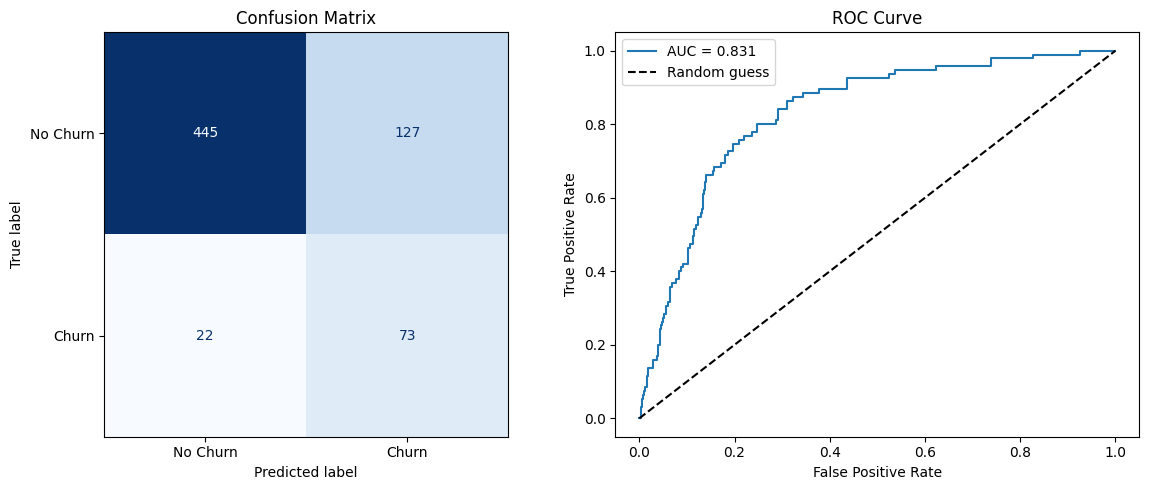

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
axes[1].plot([0, 1], [0, 1], "k--", label="Random guess")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()
